# Searchlight Results: Stimulus Category Decoding

Whole-brain searchlight analysis — 4-class stimulus category decoding (face / figure / hand / house) from GLMsingle type-D betas.  
6 mm radius sphere, LinearSVC, leave-one-run-out cross-validation, chance level = 25%.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from nilearn import image, plotting, datasets

sys.path.insert(0, str(Path('../')))
from utils.data import load_participant_list

# --- Configure these paths ---
DERIVATIVES_DIR = Path.home() / 'phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives'
SEARCHLIGHT_DIR = DERIVATIVES_DIR / 'searchlight'
VC_MASK_PATH = DERIVATIVES_DIR / 'decoding/visual_cortex_mask.nii.gz'
MASKS_DIR = Path.home() / 'phd_local/data/LearningHabits/dev_sample/masks/MNI152NLin2009cAsym'
FUSIFORM_MASK_PATH = MASKS_DIR / 'fusiform_mask_MNI152NLin2009cAsym.nii'
PARTICIPANTS_DIR = Path.home() / 'phd_local/data/LearningHabits'
PARTICIPANTS_FILE = 'participants_mvpa.tsv'
# -----------------------------

CHANCE = 0.25
ALPHA_FDR = 0.05

# Fall back to discovering subjects from directory if TSV not present
if (PARTICIPANTS_DIR / PARTICIPANTS_FILE).exists():
    subjects = load_participant_list(PARTICIPANTS_DIR, file_name=PARTICIPANTS_FILE)
else:
    subjects = sorted(p.name.replace('sub-', '') for p in SEARCHLIGHT_DIR.glob('sub-*') if p.is_dir())
print(f"Subject list: {len(subjects)} subjects")


Subject list: 59 subjects


## 1. Data Loading & Completeness Check

Check which subjects have output maps, then load them all into a 4D image and build a group brain mask.

In [2]:
# Discover per-subject searchlight maps
map_paths = {}
for sub in subjects:
    p = SEARCHLIGHT_DIR / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat.nii.gz'
    if p.exists():
        map_paths[sub] = p

missing = [s for s in subjects if s not in map_paths]
print(f"Found: {len(map_paths)} / {len(subjects)} subjects")
if missing:
    print(f"Missing: {missing}")

# Load all maps into a 4D image (subjects along 4th dim)
imgs_list = [nib.load(map_paths[s]) for s in sorted(map_paths)]
imgs_4d = image.concat_imgs(imgs_list)
print(f"4D image shape: {imgs_4d.shape}  ({imgs_4d.shape[-1]} subjects)")

# Group brain mask: MNI152 template mask resampled to searchlight space
mni_mask = datasets.load_mni152_brain_mask()
group_mask = image.resample_to_img(mni_mask, imgs_4d, interpolation='nearest')
mask_data = group_mask.get_fdata().astype(bool)
print(f"Group brain mask: {mask_data.sum()} voxels")


Found: 59 / 59 subjects
4D image shape: (53, 65, 48, 59)  (59 subjects)
Group brain mask: 59793 voxels


## 2. Group Mean Accuracy Map

Average the per-subject accuracy maps; threshold display at chance level.

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_18415/2946732320.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


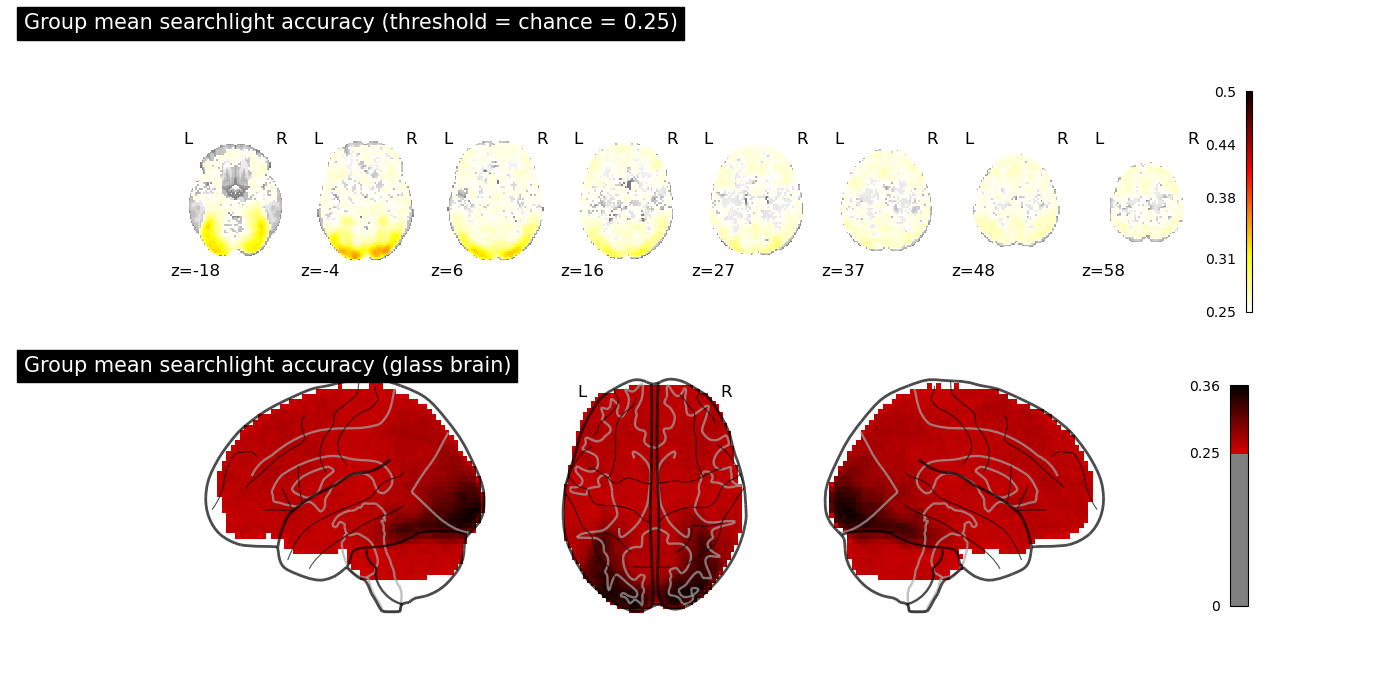

Mean accuracy in brain mask: 0.249 ± 0.040
Peak accuracy: 0.356


In [3]:
mean_img = image.mean_img(imgs_4d)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plotting.plot_stat_map(
    mean_img, threshold=CHANCE, colorbar=True,
    title=f'Group mean searchlight accuracy (threshold = chance = {CHANCE})',
    display_mode='z', cut_coords=8, axes=axes[0],
    cmap='hot_r', vmin=CHANCE, vmax=0.5
)

plotting.plot_glass_brain(
    mean_img, threshold=CHANCE, colorbar=True,
    title='Group mean searchlight accuracy (glass brain)',
    display_mode='lzr', axes=axes[1],
    cmap='hot_r', plot_abs=False
)

plt.tight_layout()
plt.show()

mean_acc_in_mask = mean_img.get_fdata()[mask_data]
print(f"Mean accuracy in brain mask: {mean_acc_in_mask.mean():.3f} ± {mean_acc_in_mask.std():.3f}")
print(f"Peak accuracy: {mean_acc_in_mask.max():.3f}")


## 3. Group Inference: Voxelwise t-test vs. Chance

One-sample t-test at each voxel (`scipy.stats.ttest_1samp`), with FDR correction across voxels.

Significant voxels (FDR q<0.05): 19693 / 59793
t-value range: -73.2 to 16.5


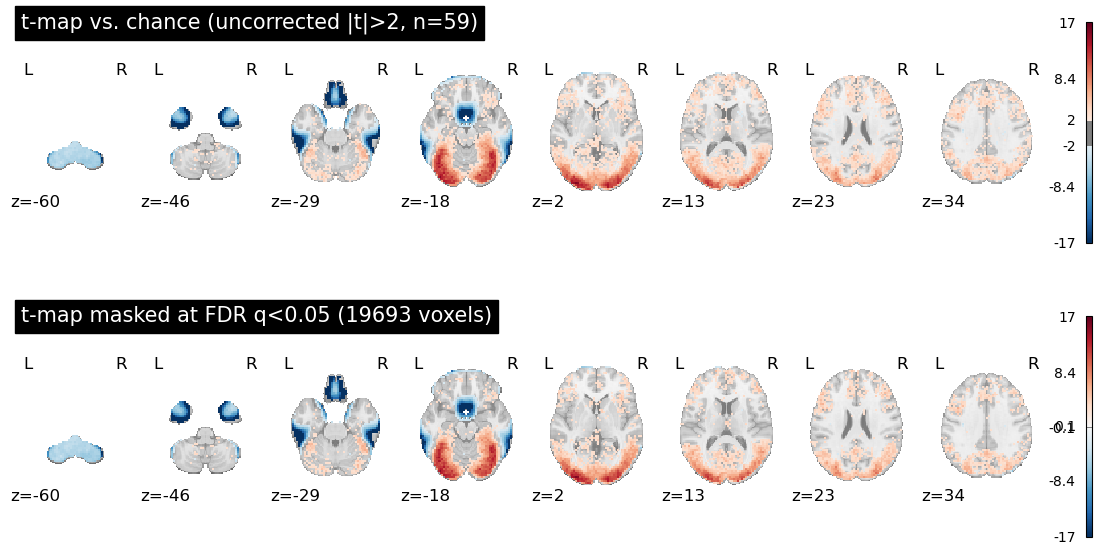

In [4]:
# Extract subjects × voxels array (mask to brain)
data_4d = imgs_4d.get_fdata()                    # shape: (x, y, z, n_subjects)
n_subjects = data_4d.shape[-1]
data_masked = data_4d[mask_data, :].T            # shape: (n_subjects, n_voxels)

# One-sample t-test vs. chance at each voxel
t_vals, p_vals = stats.ttest_1samp(data_masked, popmean=CHANCE, axis=0)

# Replace non-finite values (zero-variance edge voxels) with 0
t_vals = np.nan_to_num(t_vals, nan=0.0, posinf=0.0, neginf=0.0)
p_vals = np.nan_to_num(p_vals, nan=1.0, posinf=1.0, neginf=1.0)

# FDR correction
_, q_vals = fdrcorrection(p_vals, alpha=ALPHA_FDR)
n_sig = (q_vals < ALPHA_FDR).sum()
print(f"Significant voxels (FDR q<{ALPHA_FDR}): {n_sig} / {len(q_vals)}")
print(f"t-value range: {t_vals.min():.1f} to {t_vals.max():.1f}")

# Reconstruct NIfTI images
t_map_data = np.zeros(mask_data.shape)
t_map_data[mask_data] = t_vals
t_map_img = image.new_img_like(mean_img, t_map_data)

sig_map_data = np.zeros(mask_data.shape)
sig_map_data[mask_data] = np.where(q_vals < ALPHA_FDR, t_vals, 0.0)
sig_map_img = image.new_img_like(mean_img, sig_map_data)

T_MAX = np.percentile(np.abs(t_vals[t_vals != 0]), 99)  # cap at 99th percentile

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plotting.plot_stat_map(
    t_map_img, threshold=2.0, colorbar=True,
    title=f't-map vs. chance (uncorrected |t|>2, n={n_subjects})',
    display_mode='z', cut_coords=8, axes=axes[0],
    cmap='RdBu_r', symmetric_cbar=True, vmax=T_MAX
)

plotting.plot_stat_map(
    sig_map_img, threshold=0.1, colorbar=True,
    title=f't-map masked at FDR q<{ALPHA_FDR} ({n_sig} voxels)',
    display_mode='z', cut_coords=8, axes=axes[1],
    cmap='RdBu_r', symmetric_cbar=True, vmax=T_MAX
)

plt.show()


## 4. ROI Summary: Visual Cortex

Extract mean searchlight accuracy within the visual cortex mask (built during decoding pipeline) and compare against whole-brain average.

Visual cortex mask: 7658 voxels
Fusiform mask:      320 voxels
Whole brain: mean=0.249, t=-0.83, p=0.4076
Visual cortex: mean=0.274, t=13.60, p=0.0000
Fusiform: mean=0.297, t=17.93, p=0.0000


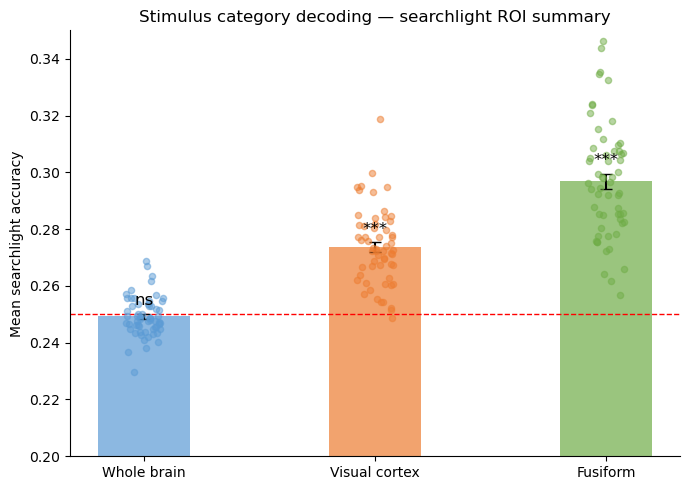

In [5]:
# Load and resample ROI masks to searchlight space
def load_roi_mask(mask_path, ref_img, brain_mask):
    roi = image.resample_to_img(str(mask_path), ref_img, interpolation='nearest')
    return roi.get_fdata().astype(bool) & brain_mask

vc_mask = load_roi_mask(VC_MASK_PATH, mean_img, mask_data)
fus_mask = load_roi_mask(FUSIFORM_MASK_PATH, mean_img, mask_data)
print(f"Visual cortex mask: {vc_mask.sum()} voxels")
print(f"Fusiform mask:      {fus_mask.sum()} voxels")

# Per-subject mean accuracy within each ROI
rois = {
    'wholebrain':    (data_4d[mask_data, :].mean(axis=0), '#5B9BD5'),
    'visual_cortex': (data_4d[vc_mask, :].mean(axis=0),  '#ED7D31'),
    'fusiform':      (data_4d[fus_mask, :].mean(axis=0), '#70AD47'),
}
roi_labels = {'wholebrain': 'Whole brain', 'visual_cortex': 'Visual cortex', 'fusiform': 'Fusiform'}

summary_df = pd.DataFrame(
    {'subject': sorted(map_paths.keys())} |
    {roi: vals for roi, (vals, _) in rois.items()}
)

# Statistical tests
for roi, (vals, _) in rois.items():
    t, p = stats.ttest_1samp(vals, CHANCE)
    print(f"{roi_labels[roi]}: mean={vals.mean():.3f}, t={t:.2f}, p={p:.4f}")

# Strip plot
fig, ax = plt.subplots(figsize=(7, 5))
rng = np.random.default_rng(0)

for pos, (roi, (vals, color)) in enumerate(rois.items()):
    sem = vals.std() / np.sqrt(len(vals))
    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(pos + jitter, vals, color=color, alpha=0.5, s=20, zorder=3)
    ax.bar(pos, vals.mean(), 0.4, yerr=sem, color=color, alpha=0.7,
           capsize=4, error_kw={'elinewidth': 1.5}, zorder=2)
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(pos, vals.mean() + sem + 0.003, sig, ha='center', fontsize=12)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1, label=f'Chance ({CHANCE})')
ax.set_xticks(range(len(rois)))
ax.set_xticklabels(roi_labels.values())
ax.set_ylim(0.20, 0.35)
ax.set_ylabel('Mean searchlight accuracy')
ax.set_title('Stimulus category decoding — searchlight ROI summary')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


Fusiform vs. visual cortex (paired t-test): t=15.11, p=9.05e-22 ***
Mean difference (fus - vc): 0.0232 ± 0.0117
Subjects where fusiform > visual cortex: 59 / 59


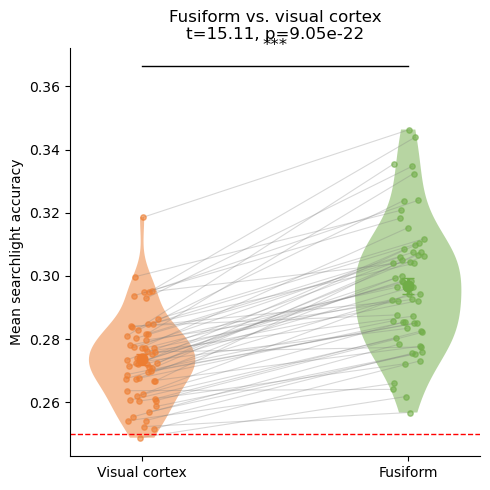

In [6]:
vc_vals = summary_df['visual_cortex'].values
fus_vals = summary_df['fusiform'].values
diff = fus_vals - vc_vals

t_comp, p_comp = stats.ttest_rel(fus_vals, vc_vals)
sig = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'ns'
print(f"Fusiform vs. visual cortex (paired t-test): t={t_comp:.2f}, p={p_comp:.2e} {sig}")
print(f"Mean difference (fus - vc): {diff.mean():.4f} ± {diff.std():.4f}")
print(f"Subjects where fusiform > visual cortex: {(diff > 0).sum()} / {len(diff)}")

fig, ax = plt.subplots(figsize=(5, 5))

positions = [0, 1]
colors = ['#ED7D31', '#70AD47']
labels = ['Visual cortex', 'Fusiform']
data = [vc_vals, fus_vals]

parts = ax.violinplot(data, positions=positions, widths=0.4,
                      showmeans=False, showmedians=False, showextrema=False)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)

rng = np.random.default_rng(0)

# Individual subject lines and dots
jitter = rng.uniform(-0.06, 0.06, len(vc_vals))
for vc, fus, j in zip(vc_vals, fus_vals, jitter):
    ax.plot([0 + j, 1 + j], [vc, fus], color='gray', alpha=0.3, linewidth=0.8, zorder=2)

for pos, vals, color in zip(positions, data, colors):
    ax.scatter(pos + jitter, vals, color=color, s=15, alpha=0.6, zorder=3)

# Mean ± SEM markers
for pos, vals, color in zip(positions, data, colors):
    sem = vals.std() / np.sqrt(len(vals))
    ax.scatter(pos, vals.mean(), color=color, s=60, zorder=5)
    ax.errorbar(pos, vals.mean(), yerr=sem, color=color, linewidth=2, capsize=4, zorder=5)

ax.axhline(CHANCE, color='red', linewidth=1, linestyle='--', label=f'Chance ({CHANCE})')

# Significance bracket
y_bracket = max(vc_vals.max(), fus_vals.max()) + 0.02
ax.plot([0, 1], [y_bracket, y_bracket], color='black', linewidth=1)
ax.text(0.5, y_bracket + 0.005, sig, ha='center', fontsize=12)

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean searchlight accuracy')
ax.set_title(f'Fusiform vs. visual cortex\nt={t_comp:.2f}, p={p_comp:.2e}')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Individual Subject Maps (Spot-check)

Plot accuracy maps for subjects spanning the distribution of visual cortex accuracy (worst, 25th, median, 75th, best percentile).

Outliers (>3 SD): ['21']


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_18415/572414209.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


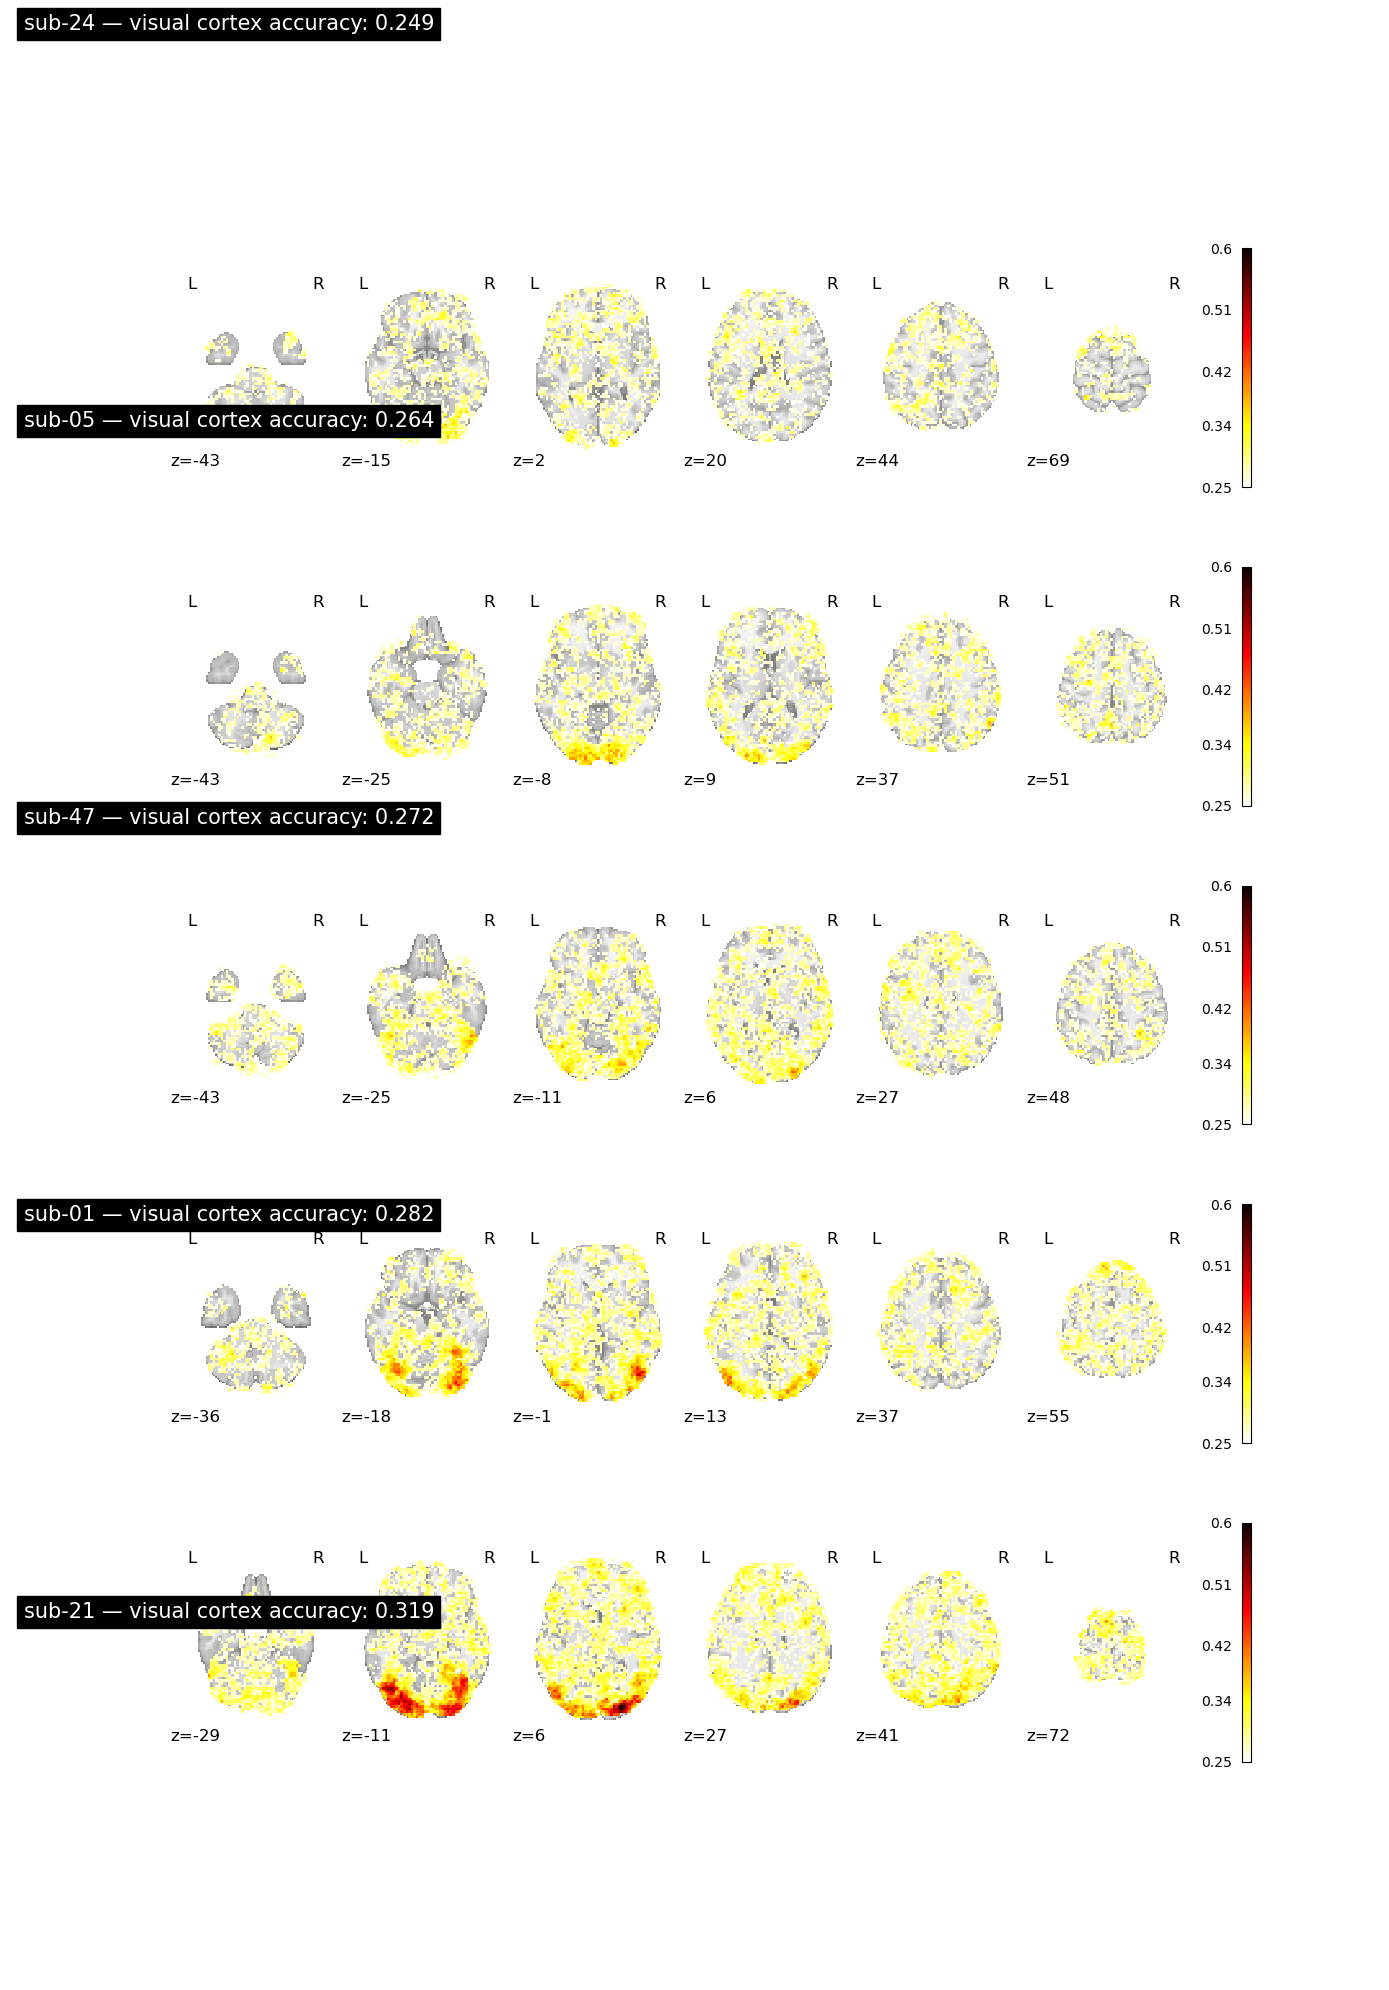

In [7]:
# Select representative subjects by visual cortex accuracy
subs_sorted = summary_df.sort_values('visual_cortex').subject.tolist()
n_subs = len(subs_sorted)

spotlight_indices = [0, n_subs // 4, n_subs // 2, 3 * n_subs // 4, n_subs - 1]
spotlight_subs = [subs_sorted[i] for i in spotlight_indices]

# Flag outliers (>3 SD from mean)
mean_vc = summary_df.visual_cortex.mean()
std_vc = summary_df.visual_cortex.std()
outliers = summary_df[np.abs(summary_df.visual_cortex - mean_vc) > 3 * std_vc]
if len(outliers):
    print(f"Outliers (>3 SD): {outliers.subject.tolist()}")
else:
    print("No outliers detected")

fig, axes = plt.subplots(len(spotlight_subs), 1, figsize=(14, 4 * len(spotlight_subs)))

for ax, sub in zip(axes, spotlight_subs):
    sub_img = nib.load(map_paths[sub])
    vc_acc = summary_df.loc[summary_df.subject == sub, 'visual_cortex'].values[0]
    plotting.plot_stat_map(
        sub_img, threshold=CHANCE, colorbar=True,
        title=f'sub-{sub} — visual cortex accuracy: {vc_acc:.3f}',
        display_mode='z', cut_coords=6, axes=ax,
        cmap='hot_r', vmin=CHANCE, vmax=0.6
    )

plt.tight_layout()
plt.show()


## 6. Per-category Accuracy Maps

One-vs-rest binary searchlight per stimulus category. Chance = 0.75 (majority-class baseline: always predicting "rest" gives 75% with 4 balanced categories).

face: loaded 59 subjects, shape (53, 65, 48, 59)
figure: loaded 59 subjects, shape (53, 65, 48, 59)
hand: loaded 59 subjects, shape (53, 65, 48, 59)
house: loaded 59 subjects, shape (53, 65, 48, 59)


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_18415/2154053108.py:26: UserWarning: empty mask
  plotting.plot_stat_map(


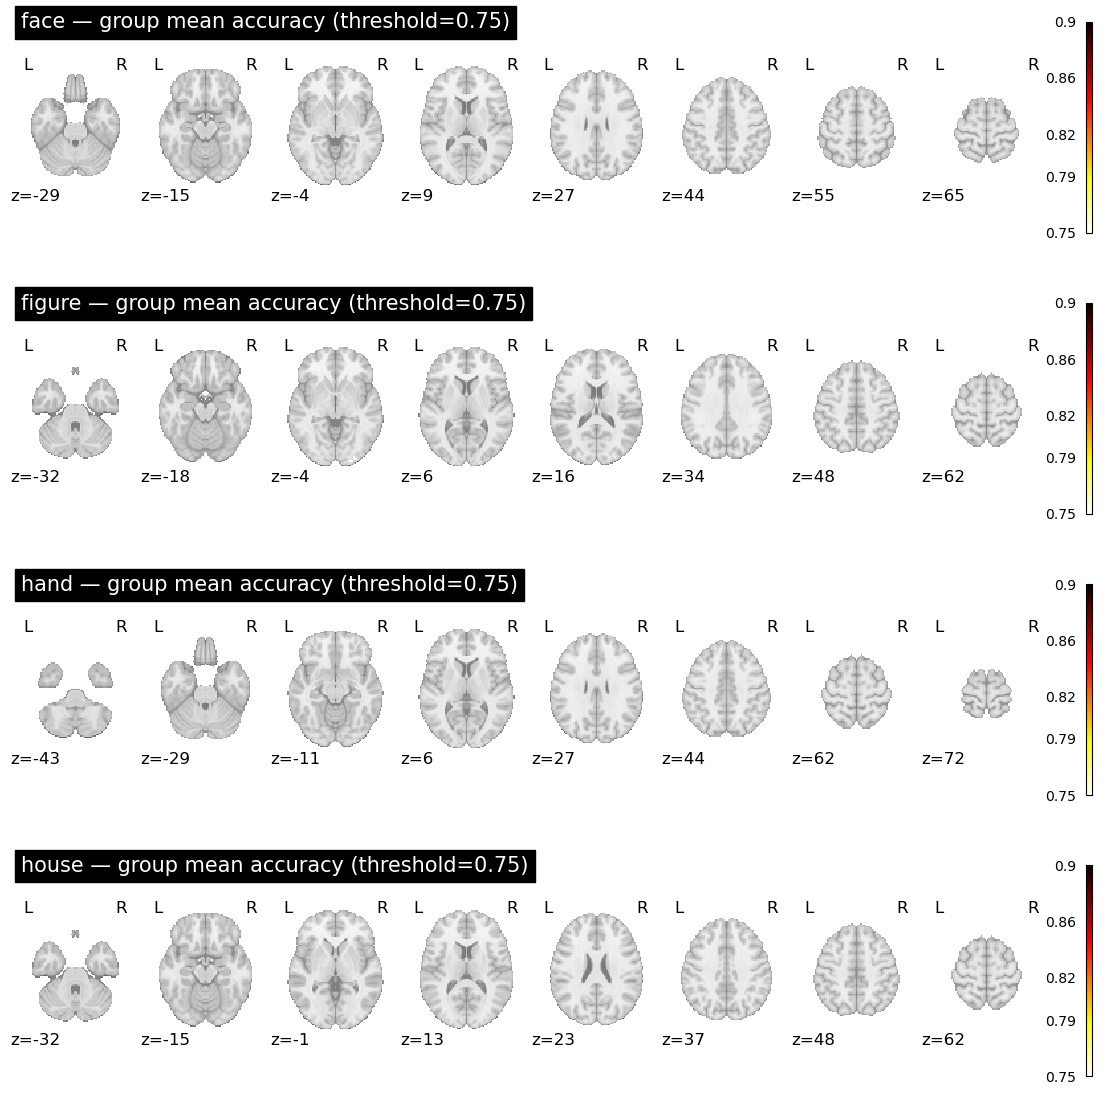

In [8]:
STIM_CATS = ['face', 'figure', 'hand', 'house']
CHANCE_BINARY = 1 - 1 / len(STIM_CATS)  # 0.75

# Load per-category 4D images
cat_imgs_4d = {}
cat_missing = {}
for cat in STIM_CATS:
    paths = []
    missing = []
    for sub in sorted(map_paths):
        p = SEARCHLIGHT_DIR / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_{cat}.nii.gz'
        if p.exists():
            paths.append(p)
        else:
            missing.append(sub)
    if missing:
        print(f"{cat}: missing {len(missing)} subjects — {missing}")
    cat_imgs_4d[cat] = image.concat_imgs([nib.load(p) for p in paths])
    print(f"{cat}: loaded {len(paths)} subjects, shape {cat_imgs_4d[cat].shape}")

# Group mean maps
cat_mean_imgs = {cat: image.mean_img(img) for cat, img in cat_imgs_4d.items()}

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, cat in zip(axes, STIM_CATS):
    plotting.plot_stat_map(
        cat_mean_imgs[cat], threshold=CHANCE_BINARY, colorbar=True,
        title=f'{cat} — group mean accuracy (threshold={CHANCE_BINARY})',
        display_mode='z', cut_coords=8, axes=ax,
        cmap='hot_r', vmin=CHANCE_BINARY, vmax=0.9
    )
plt.show()


## 7. Per-category Group Inference

Voxelwise one-sample t-test vs. `CHANCE_BINARY` (0.75), FDR corrected.

face: 59793 significant voxels (FDR q<0.05)
figure: 59541 significant voxels (FDR q<0.05)
hand: 59793 significant voxels (FDR q<0.05)
house: 59793 significant voxels (FDR q<0.05)


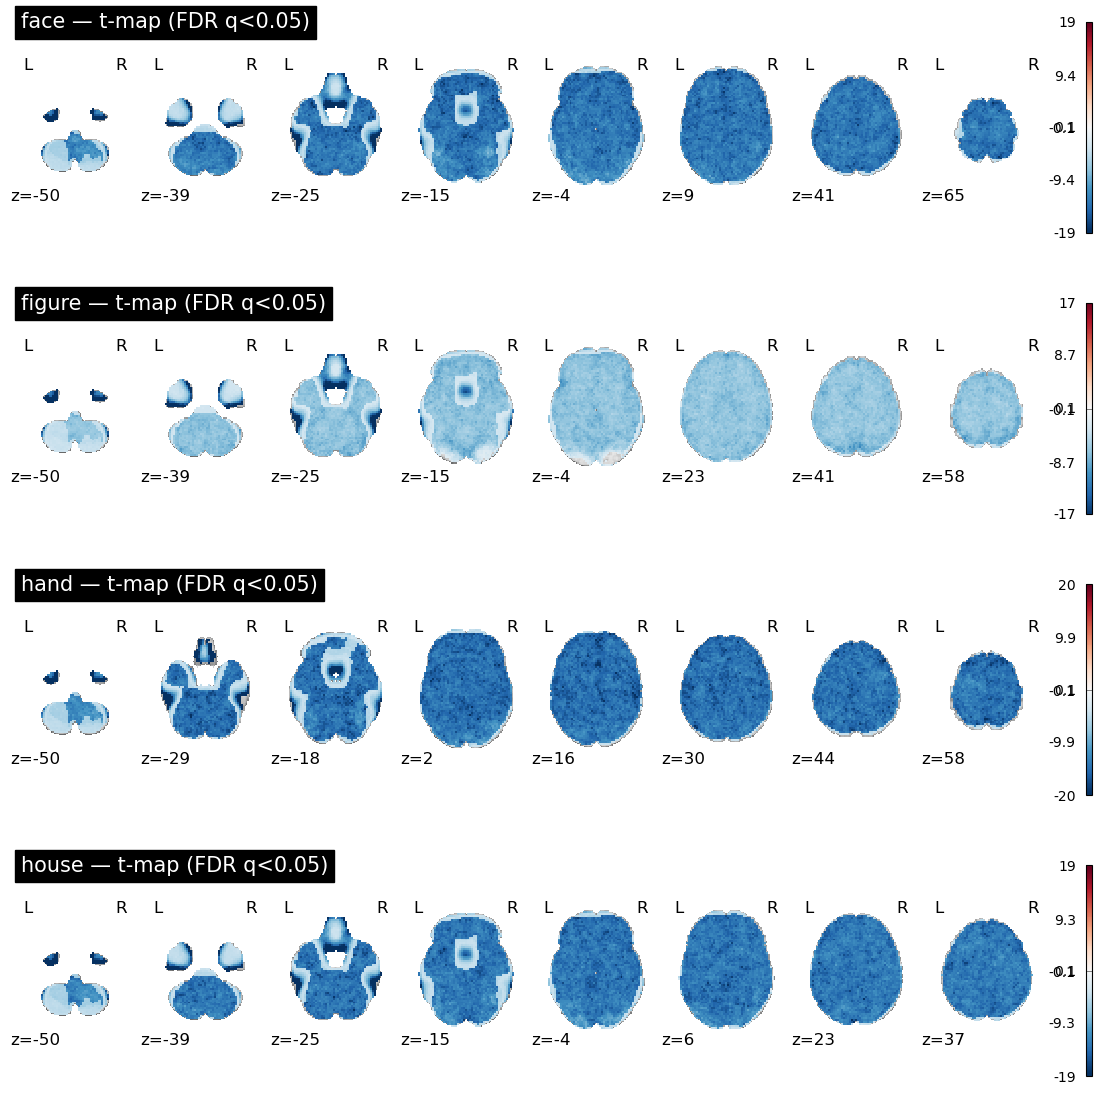

In [9]:
cat_sig_imgs = {}

for cat in STIM_CATS:
    data = cat_imgs_4d[cat].get_fdata()[mask_data, :].T   # (n_subjects, n_voxels)
    t_vals, p_vals = stats.ttest_1samp(data, popmean=CHANCE_BINARY, axis=0)
    t_vals = np.nan_to_num(t_vals, nan=0.0, posinf=0.0, neginf=0.0)
    p_vals = np.nan_to_num(p_vals, nan=1.0)
    _, q_vals = fdrcorrection(p_vals, alpha=ALPHA_FDR)
    n_sig = (q_vals < ALPHA_FDR).sum()
    print(f"{cat}: {n_sig} significant voxels (FDR q<{ALPHA_FDR})")

    sig_data = np.zeros(mask_data.shape)
    sig_data[mask_data] = np.where(q_vals < ALPHA_FDR, t_vals, 0.0)
    cat_sig_imgs[cat] = image.new_img_like(mean_img, sig_data)

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, cat in zip(axes, STIM_CATS):
    t_max = np.percentile(np.abs(cat_sig_imgs[cat].get_fdata()[mask_data]), 99)
    plotting.plot_stat_map(
        cat_sig_imgs[cat], threshold=0.1, colorbar=True,
        title=f'{cat} — t-map (FDR q<{ALPHA_FDR})',
        display_mode='z', cut_coords=8, axes=ax,
        cmap='RdBu_r', symmetric_cbar=True, vmax=t_max if t_max > 0 else 1
    )
plt.show()


## 8. Per-category ROI Summary

Mean one-vs-rest accuracy per category within each ROI.

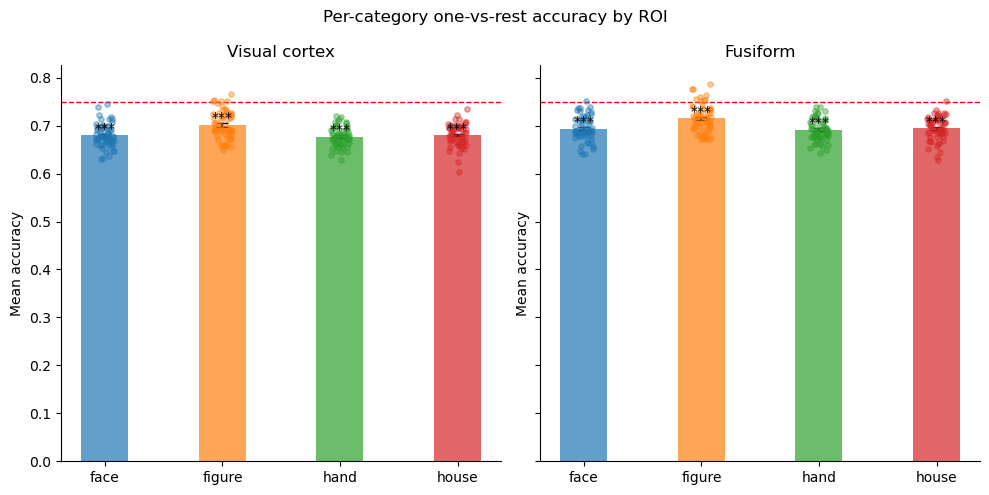

In [10]:
roi_masks = {'Visual cortex': vc_mask, 'Fusiform': fus_mask}
cat_colors = dict(zip(STIM_CATS, [plt.cm.tab10(i) for i in range(len(STIM_CATS))]))

fig, axes = plt.subplots(1, len(roi_masks), figsize=(5 * len(roi_masks), 5), sharey=True)

for ax, (roi_label, roi_mask) in zip(axes, roi_masks.items()):
    # Per-subject, per-category mean accuracy in this ROI
    roi_data = {cat: cat_imgs_4d[cat].get_fdata()[roi_mask, :].mean(axis=0)
                for cat in STIM_CATS}

    x = np.arange(len(STIM_CATS))
    rng = np.random.default_rng(0)

    for i, cat in enumerate(STIM_CATS):
        vals = roi_data[cat]
        sem = vals.std() / np.sqrt(len(vals))
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(i + jitter, vals, color=cat_colors[cat], alpha=0.4, s=15, zorder=3)
        ax.bar(i, vals.mean(), 0.4, yerr=sem, color=cat_colors[cat], alpha=0.7,
               capsize=4, error_kw={'elinewidth': 1.5}, zorder=2)
        t, p = stats.ttest_1samp(vals, CHANCE_BINARY)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(i, vals.mean() + sem + 0.002, sig, ha='center', fontsize=10)

    ax.axhline(CHANCE_BINARY, color='red', linewidth=1, linestyle='--',
               label=f'Chance ({CHANCE_BINARY})')
    ax.set_xticks(x)
    ax.set_xticklabels(STIM_CATS)
    ax.set_title(roi_label)
    ax.set_ylabel('Mean accuracy')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Per-category one-vs-rest accuracy by ROI')
plt.tight_layout()
plt.show()
